In [1]:
#imports
import sklearn
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = "paste your file path here"

In [6]:
feature_length = 4096  # all features have this length

feature_description = {
    'tmmx': tf.io.FixedLenFeature([feature_length], tf.float32),
    'FireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'th': tf.io.FixedLenFeature([feature_length], tf.float32),
    'erc': tf.io.FixedLenFeature([feature_length], tf.float32),
    'vs': tf.io.FixedLenFeature([feature_length], tf.float32),
    'elevation': tf.io.FixedLenFeature([feature_length], tf.float32),
    'tmmn': tf.io.FixedLenFeature([feature_length], tf.float32),
    'NDVI': tf.io.FixedLenFeature([feature_length], tf.float32),
    'sph': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pdsi': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pr': tf.io.FixedLenFeature([feature_length], tf.float32),
    'population': tf.io.FixedLenFeature([feature_length], tf.float32),
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

dataset = tf.data.TFRecordDataset(file_path)
parsed_dataset = dataset.map(_parse_function)

# Define the list of feature names and the label name
features_to_extract = ['tmmx', 'PrevFireMask', 'th', 'erc', 'vs', 'elevation',
                       'tmmn', 'NDVI', 'sph', 'pdsi', 'pr', 'population']
label_to_extract = 'FireMask'

# Initialize lists to hold the extracted data
all_features_data = []
all_labels_data = []


In [7]:
for parsed_record in parsed_dataset:
    # Concatenate all specified features for the current record into a single flat array
    current_sample_features = np.concatenate([parsed_record[f].numpy() for f in features_to_extract])
    all_features_data.append(current_sample_features)

    # Extract the label (FireMask) for the current record
    all_labels_data.append(parsed_record[label_to_extract].numpy())

# Convert the lists of data into numpy arrays
X = np.array(all_features_data)
y = np.array(all_labels_data)


print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

In [8]:
# Full dataset
#Splits the data into training and testing sets
# Assuming X contains features and y contains target variable (labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [9]:
#max_depth is taken from the paper, where they found max depth of 15 to be the best
rf_model = RandomForestClassifier(n_jobs =-1, max_depth=15)

rf_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = rf_model.predict(X_test)

print('success')


In [10]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, precision_score, recall_score, f1_score

precision, recall, fb, support = precision_recall_fscore_support(y_test.flatten(), predictions.flatten(), average='macro')

accuracy = accuracy_score(y_test.flatten(), predictions.flatten())
print(f"Accuracy: {accuracy}")

print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.968870849609375
Precision: 0.8665175362028399
Recall: 0.38751055577718074


In [ ]:
#Prediction visualization
single_prediction = predictions[9].reshape(64, 64)
print(single_prediction.shape)
plt.figure(figsize=(10, 10))
plt.title(f"Prediction of a single record")
plt.imshow(single_prediction, cmap='Reds')
plt.colorbar()
plt.show()
means = []
means.append(y_test.mean())
means.append(predictions.mean())
print(means)

In [ ]:
num_to_skip = 2

single_record = dataset.map(_parse_function).skip(num_to_skip).take(1)

features_data = []
labels_data = []

for parsed_record in single_record:
    # Concatenate all specified features for the current record into a single flat array
    current_sample_features = np.concatenate([parsed_record[f].numpy() for f in features_to_extract])
    features_data.append(current_sample_features)

    # Extract the label (FireMask) for the current record
    labels_data.append(parsed_record[label_to_extract].numpy())

# Convert the lists of data into numpy arrays
X_single = np.array(features_data)
y_single = np.array(labels_data)


print(f"Shape of features (X): {X_single.shape}")
print(f"Shape of labels (y): {y_single.shape}")

Shape of features (X): (1, 49152)
Shape of labels (y): (1, 4096)


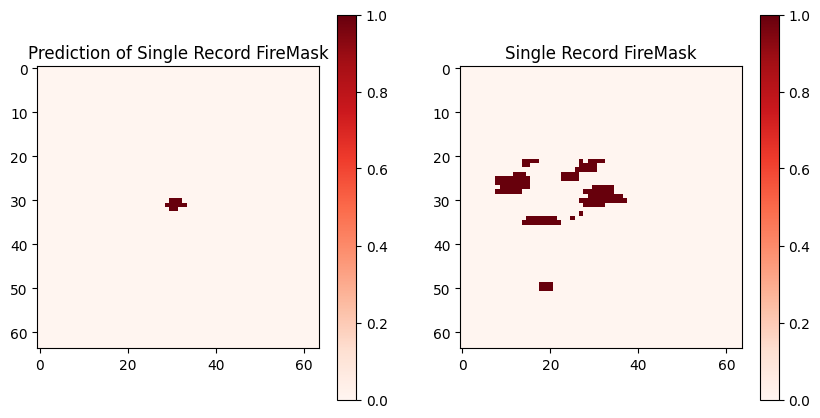

In [12]:
single_record_prediction = rf_model.predict(X_single)

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.title(f"Prediction of Single Record FireMask")
plt.imshow(single_record_prediction.reshape(64,64), cmap="Reds")
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Single Record FireMask")
plt.imshow(y_single.reshape(64,64), cmap="Reds")
plt.colorbar()


plt.show()